# **Setup**

In [90]:
%pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [91]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

from pathlib import Path
data_candidates = [Path("titanic.csv"), Path("titanic.csv")]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Keep titanice.csv beside this notebook")

df = pd.read_csv(data_path)
df.columns = df.columns.str.strip().str.lower()
print(f"loaded {df.shape[0]}, passenger survival rate {df["survived"].mean():.1%}")
df.head()

loaded 1000, passenger survival rate 44.0%


,survived,pclass,sex,age,sibsp,parch,fare
0,1,2,female,17.8,0,0,23.94
1,0,3,male,18.5,1,0,29.07
2,0,3,male,26.6,1,0,17.63
3,0,3,male,34.7,0,2,13.72
4,1,1,male,42.0,0,0,128.90


In [92]:
from sklearn.model_selection import train_test_split

df["age"] = df.groupby(["pclass", "sex"])["age"].transform(lambda X: X.fillna(X.median()))
df["fare"] = df["fare"].fillna(df['fare'].median())
df["sex_male"] = (df["sex"] == 'male').astype(float)

features = ["pclass", "sex_male", "age", "sibsp", "parch", "fare"]
if "embarked" in df.columns:
    df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
    df["embarked_Q"] = (df["embarked"] == "Q").astype(float)
    df["embarked_S"] = (df["embarked"] == "S").astype(float)
    features += ["embarked_Q", "embarked_S"]

X = df[features].astype(float)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features", features)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

Features ['pclass', 'sex_male', 'age', 'sibsp', 'parch', 'fare']
X_train Shape: (800, 6)
X_test Shape: (200, 6)


# **Part A — Build boosting before you use it**
## **TASK 01 — Residuals by hand**

In [93]:
baseline_prediction = y_train.mean()
print("Baseline Prediction:", baseline_prediction)

Baseline Prediction: 0.44


In [94]:
# Create prediction for every training passenger
baseline_predictions = np.full(len(y_train), baseline_prediction)

baseline_predictions[:10]

array([0.44, 0.44, 0.44, 0.44, 0.44, 0.44, 0.44, 0.44, 0.44, 0.44])

In [95]:
# residual
residual = y_train.values - baseline_predictions

residual[:10]

array([-0.44, -0.44,  0.56, -0.44,  0.56, -0.44,  0.56, -0.44,  0.56,
        0.56])

In [96]:
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
# Calculate MSE
baseline_mse = mean_squared_error(y_train, baseline_predictions)
print("Baseline MSE:", baseline_mse)

Baseline MSE: 0.2464


In [97]:
# First 10 residuals alongside actual values
residual_df = pd.DataFrame({
    "Actual_survived": y_train.values[:10],
    "baseline_prediction": baseline_predictions[:10],
    "residual": residual[:10]
})

residual_df

,Actual_survived,baseline_prediction,residual
0,0,0.44,-0.44
1,0,0.44,-0.44
2,1,0.44,0.56
3,0,0.44,-0.44
4,1,0.44,0.56
5,0,0.44,-0.44
6,1,0.44,0.56
7,0,0.44,-0.44
8,1,0.44,0.56
9,1,0.44,0.56


### **Markdown**

* For a passenger who survived (actual = 1), the residual is positive because the baseline prediction is below 1.
* For a passenger who not survived (actual = 0), the residual is negative because the baseline prediction is above 0.
* The sign of the residual tells us which direction the prediction needs to move. A positive residual means the prediction needs to increase, while a negative residual means the prediction needs to decrease.
* Therefore, a residual is the error that is still left over after the current prediction.

### **TASK 02 — Build a gradient booster with a loop**

In [98]:
from sklearn.tree import DecisionTreeRegressor

prediction = np.full(len(y_train), y_train.mean())
learning_rate = 0.3
trees, training_mse = [], []

# build a booster for 30 rounds
for round_num in range(30):
    residual = y_train.values - prediction
    tree = DecisionTreeRegressor(max_depth=2, random_state=round_num).fit(X_train, residual)
    prediction += learning_rate * tree.predict(X_train)
    trees.append(tree)
    mse = mean_squared_error(y_train, prediction)
    training_mse.append(mse)

for i, mse in enumerate(training_mse, start=1):
    print(f"Round{i}: Training MSE = {mse:.4f}")

Round1: Training MSE = 0.2086
Round2: Training MSE = 0.1887
Round3: Training MSE = 0.1788
Round4: Training MSE = 0.1731
Round5: Training MSE = 0.1700
Round6: Training MSE = 0.1674
Round7: Training MSE = 0.1655
Round8: Training MSE = 0.1642
Round9: Training MSE = 0.1630
Round10: Training MSE = 0.1617
Round11: Training MSE = 0.1604
Round12: Training MSE = 0.1592
Round13: Training MSE = 0.1580
Round14: Training MSE = 0.1571
Round15: Training MSE = 0.1562
Round16: Training MSE = 0.1556
Round17: Training MSE = 0.1552
Round18: Training MSE = 0.1543
Round19: Training MSE = 0.1536
Round20: Training MSE = 0.1530
Round21: Training MSE = 0.1521
Round22: Training MSE = 0.1514
Round23: Training MSE = 0.1511
Round24: Training MSE = 0.1503
Round25: Training MSE = 0.1500
Round26: Training MSE = 0.1495
Round27: Training MSE = 0.1491
Round28: Training MSE = 0.1478
Round29: Training MSE = 0.1468
Round30: Training MSE = 0.1452


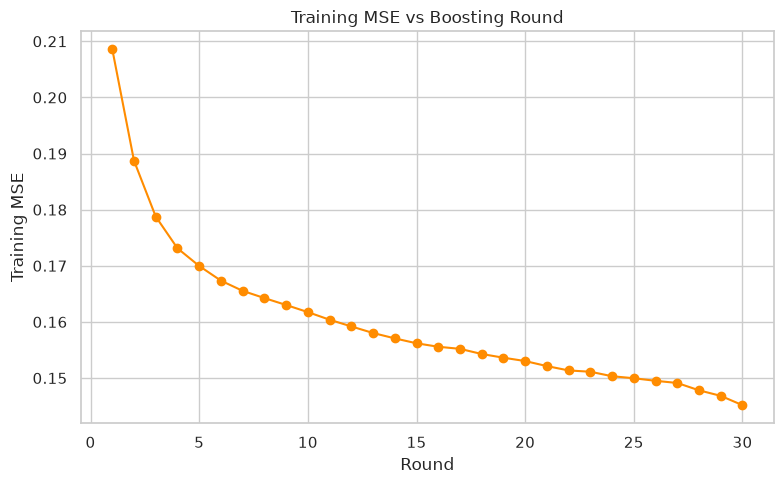

In [99]:
# plot training mse
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 31), training_mse, marker="o", color="darkorange")
ax.set_title("Training MSE vs Boosting Round")
ax.set_xlabel("Round")
ax.set_ylabel("Training MSE")
ax.grid(True)
plt.tight_layout()
plt.show()

In [100]:
# Prediction Function
def predict_boosting(X):
    prediction = np.full(len(X), y_train.mean())  # Baseline prediction
    for tree in trees:
        prediction += learning_rate * tree.predict(X)  # Apply every tree in order

    return prediction

# Predict on test data
test_prediction = predict_boosting(X_test)
print("First 10 test prediction:")
print(test_prediction[:10])

First 10 test prediction:
[0.9028243  0.3353134  0.92331673 0.08379403 0.4209348  0.34526361
 0.17890394 0.90454232 0.62699643 0.50106902]


In [101]:
test_labels = (test_prediction >= 0.5).astype(int)

# test accuracy 
test_acc = accuracy_score(y_test, test_labels)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.775


In [102]:
# Test ROC-AUC
test_roc_auc = roc_auc_score(y_test, test_prediction)
print("Test ROC-AUC:", round(test_roc_auc, 4))

Test ROC-AUC: 0.8833


In [103]:
# Final Results
print("Hand-Built Gradient Booster Results")
print("-" * 35)

print("Number of Trees:", len(trees))
print("Test Accuracy:", round(test_acc, 4))
print(f"Test ROC-AUC: {test_roc_auc:.4f}")

Hand-Built Gradient Booster Results
-----------------------------------
Number of Trees: 30
Test Accuracy: 0.775
Test ROC-AUC: 0.8833


### **TASK 03 — Bagging and boosting, side by side**

In [104]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)

# Predictions
rf_train_prob = rf.predict_proba(X_train)[:, 1]
rf_test_prob = rf.predict_proba(X_test)[:, 1]

rf_test_pred = rf.predict(X_test)

# Metrics
rf_acc = accuracy_score(y_test, rf_test_pred)
rf_train_roc = roc_auc_score(y_train, rf_train_prob)
rf_test_roc = roc_auc_score(y_test, rf_test_prob)

# Gap
rf_roc_gap = rf_train_roc - rf_test_roc

print(f"Random Forest Accuracy      : {rf_acc:.4f}")
print(f"Train Random Forest ROC-AUC : {rf_train_roc:.4f}")
print(f"Test Random Forest ROC-AUC  : {rf_test_roc:.4f}")
print(f"Total ROC-AUC Gap           : {rf_roc_gap:.4f}")

Random Forest Accuracy      : 0.7400
Train Random Forest ROC-AUC : 1.0000
Test Random Forest ROC-AUC  : 0.8312
Total ROC-AUC Gap           : 0.1688


In [105]:
# XG Boost (Boosting)
xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, eval_metric="logloss",
                             random_state=42).fit(X_train, y_train)

# Predictions
xgb_train_prob = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test) [:, 1]

xgb_test_pred = xgb_model.predict(X_test)

# Metrics
xgb_acc = accuracy_score(y_test, xgb_test_pred)
xgb_train_roc = roc_auc_score(y_train, xgb_train_prob)
xgb_test_roc = roc_auc_score(y_test, xgb_test_prob)

# Gap
xgb_roc_gap = xgb_train_roc - xgb_test_roc

print(f"XGB Accuracy      : {xgb_acc:.4f}")
print(f"Train XGB ROC-AUC : {xgb_train_roc:.4f}")
print(f"Test XGB ROC-AUC  : {xgb_test_roc:.4f}")
print(f"Total ROC-AUC Gap : {xgb_roc_gap:.4f}")

XGB Accuracy      : 0.7350
Train XGB ROC-AUC : 0.9519
Test XGB ROC-AUC  : 0.8452
Total ROC-AUC Gap : 0.1067


In [106]:
# Comparison Table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Test Accuracy": [rf_acc, xgb_acc],
    "Training ROC-AUC": [rf_train_roc, xgb_train_roc],
    "Test ROC-AUC": [rf_test_roc, xgb_test_roc],
    "Train-Test AUC Gap": [rf_roc_gap, xgb_roc_gap]
})


comparison

,Model,Test Accuracy,Training ROC-AUC,Test ROC-AUC,Train-Test AUC Gap
0,Random Forest,0.740,1.00000,0.831169,0.168831
1,XGBoost,0.735,0.95186,0.845170,0.106689


In [142]:
comparison.to_csv("same-split_Comparison.csv", index=False)

# **Part B — Control the model before you trust it**
## **TASK 04 — Early stopping**

In [107]:
# Train XGBoost with Early Stopping
early_model = XGBClassifier(n_estimators=1000, learning_rate=0.1, 
                           max_depth=3, eval_metric="logloss", 
                           early_stopping_rounds=30, random_state=42)

early_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
               verbose=False)

# Find the best iteration
print("Best Iteration:", early_model.best_iteration)

Best Iteration: 91


In [108]:
# Test ROC-AUC
early_test_prob = early_model.predict_proba(X_test)[:, 1]

early_test_auc = roc_auc_score(y_test, early_test_prob)

print("Early Stopping Test ROC-AUC:", round(early_test_auc, 4))

Early Stopping Test ROC-AUC: 0.8823


In [109]:
# Compare it with the Task 03 300-Tree model
original_test_prob = xgb_model.predict_proba(X_test)[:, 1]

original_test_auc = roc_auc_score(y_test, original_test_prob)

print(f"300-tree XGBoost Test ROC-AUC       : {original_test_auc:.4f}")
print(f"Early stopping XGBoost Test ROC-AUC : {early_test_auc:.4f}")

300-tree XGBoost Test ROC-AUC       : 0.8452
Early stopping XGBoost Test ROC-AUC : 0.8823


In [140]:
# Extract the evaluation results
results = early_model.evals_result()

results

{'validation_0': OrderedDict([('logloss',
               [0.6556129638850688,
                0.6308338350057602,
                0.6103174070641398,
                0.5932202300801873,
                0.578871837966144,
                0.5667714180797339,
                0.5565320648252964,
                0.5477089408040047,
                0.5401814221963286,
                0.5336727251484991,
                0.5275029535219073,
                0.5220267119631171,
                0.5175913292914629,
                0.5133167469501495,
                0.5095335948094726,
                0.5063927822187543,
                0.5033232778310776,
                0.5002701520174742,
                0.4977752132155001,
                0.49451176182366907,
                0.49247007494792344,
                0.490010423399508,
                0.4879565353877842,
                0.48590934593230484,
                0.48390189044177534,
                0.48220293895341454,
                0.4

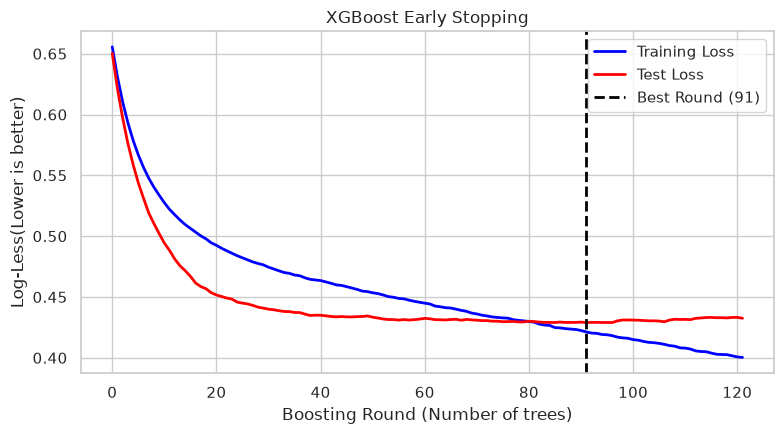

In [141]:
# Plot training and validation log-loss
train_loss = results["validation_0"]["logloss"]
test_loss = results["validation_1"]["logloss"]

fig, ax = plt.subplots()
ax.plot(train_loss, label="Training Loss", color="blue", lw=2)
ax.plot(test_loss, label="Test Loss", color="red", lw=2)
ax.axvline(early_model.best_iteration, color="black", ls="--", lw=2,
          label=f"Best Round ({early_model.best_iteration})")
ax.set_title("XGBoost Early Stopping")
ax.set_xlabel("Boosting Round (Number of trees)")
ax.set_ylabel("Log-Less(Lower is better)")
ax.legend()
plt.tight_layout()
plt.savefig("Early_Stopping.png", dpi=300, bbox_inches="tight")
plt.show()

# Conclusion 1 --> Did early stopping make the test score worse or better?  

* The 300-tree XGBoost model achieved a test ROC-AUC of **0.8452**, while the early-stopped model achieved **0.8823**.
* Therefore, early stopping made the test ROC-AUC **better**.
* This is not a contradiction because early stopping is designed to prevent overfitting. Adding more boosting rounds does not necessarily improve performance on unseen data. The model can continue improving its performance on the training data while starting to fit noise in the data, causing validation/test performance to stop improving or become worse.

# Conclusion 2 --> What do the curves show?

* The training logloss generally continues to decrease as more boosting rounds are added. However, after the validation logloss reaches its minimum and starts to increase, the two curves begin to diverge.
* This divergence indicates that the model is continuing to learn the training data very closely, while its performance on unseen validation data is getting worse. This is a sign of **overfitting**.
* Early stopping detects this behavior and stops the boosting process after the validation score has failed to improve for the specified number of rounds. Therefore, it helps select a model before excessive fitting to the training data occurs.

### **TASK 05 — The learning-rate and tree-count trade-off**

In [112]:
# Learning rate and tree count pairs
settings = [
    (0.3, 50),
    (0.1, 150),
    (0.05, 300),
    (0.01, 1500)
]

results = []

for lr, n_est in settings:
    model = xgb.XGBClassifier(n_estimators=n_est, learning_rate=lr, max_depth=3,
                             eval_matric="logloss", random_state=42).fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    results.append({
        "Learning Rate" : lr,
        "n_estimators"  : n_est,
        "Test ROC-AUC"  : auc
    })

paired_results = pd.DataFrame(results)

paired_results

,Learning Rate,n_estimators,Test ROC-AUC
0,0.30,50,0.861607
1,0.10,150,0.870485
2,0.05,300,0.869420
3,0.01,1500,0.871956


In [113]:
# Break the pairing deliberately
broken_settings = [
    (0.01, 50),
    (0.3, 1500)
]

broken_results = []

for lr, n_est in broken_settings:
    m = xgb.XGBClassifier(n_estimators=n_est, learning_rate=lr, max_depth=3,
                         eval_metric="logloss", random_state=42).fit(X_train, y_train)
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])

    broken_results.append({
        "Learning Rate" : lr,
        "n_estimators"  : n_est,
        "Test ROC-AUC"  : auc
    })

broken_result = pd.DataFrame(broken_results)

broken_result

,Learning Rate,n_estimators,Test ROC-AUC
0,0.01,50,0.876015
1,0.30,1500,0.770495


## **Conclusion -->**  
* The experiment shows that `learning_rate` and `n_estimators` are closely related. A higher learning rate allows each tree to make a larger contribution, so fewer trees may be required. A lower learning rate makes smaller updates, so more trees are generally needed to reach a similar level of performance.
* The broken pair `(learning_rate=0.01, n_estimators=50)` underperforms because the learning rate is very small and only 50 trees are allowed. Each tree makes only a small correction, and there are not enough boosting rounds for the model to learn the pattern in the data effectively. This can result in underfitting.
* The broken pair `(learning_rate=0.3, n_estimators=1500)` carries the opposite risk. The learning rate is large, so each tree makes a relatively strong correction. Allowing 1500 trees gives the model many opportunities to keep fitting the training data. This increases the risk of overfitting and can make the model unnecessarily complex.

## **Practice Rule -->**  
* The `learning_rate` should be chosen by judgement, while the number of trees (`n_estimators`) should preferably be allowed to be determined by early stopping.
* In practice, choose a reasonable learning rate such as 0.05 or 0.1, give XGBoost a deliberately large `n_estimators` value, and use early stopping to determine how many boosting rounds are actually needed.
* This avoids having to manually guess the exact number of trees.

## **TASK 06 — Find the overfitting dial**

In [114]:
depths = [2, 3, 5, 8]

results = []

for depth in depths:
    model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=depth,
                             eval_metric="logloss", random_state=42).fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    gap = train_auc - test_auc

    results.append({
        "Depth" : depth,
        "Train AUC" : train_auc,
        "Test AUC" : test_auc,
        "Gap" : gap
    })

depth_results = pd.DataFrame(results)

depth_results

,Depth,Train AUC,Test AUC,Gap
0,2,0.887381,0.875101,0.012280
1,3,0.932085,0.863738,0.068347
2,5,0.990190,0.827516,0.162674
3,8,0.999924,0.796875,0.203049


In [115]:
depth_results.to_csv("max_depth table.csv", index=False)

In [116]:
# Find the depth with the best test score
best_row = depth_results.loc[
    depth_results["Test AUC"].idxmax()
]

print("Best Depth :", best_row["Depth"])
print("Best Test ROC-AUC :", round(best_row["Test AUC"], 4))

Best Depth : 2.0
Best Test ROC-AUC : 0.8751


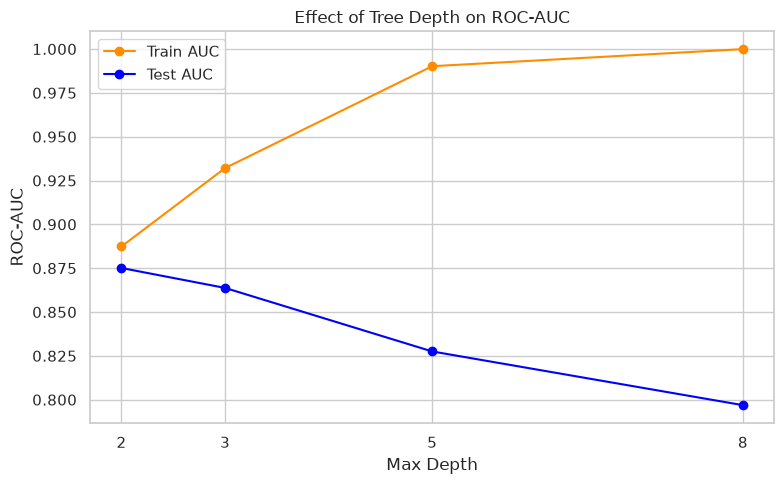

In [117]:
# Plot Train AUC vs Test AUC
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_results["Depth"], depth_results["Train AUC"], marker="o", color="darkorange", label="Train AUC")
ax.plot(depth_results["Depth"], depth_results["Test AUC"], marker="o", color="blue", label="Test AUC")
ax.set_xlabel("Max Depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Effect of Tree Depth on ROC-AUC")
ax.set_xticks(depths)
ax.legend()
plt.tight_layout()
plt.show()

## **Conclusion -->**  
* The experiment shows that `max_depth` is an important control for overfitting in XGBoost.
* As tree depth increases, the model becomes more complex and is able to capture more detailed patterns in the training data. This generally increases training ROC-AUC. However, after a certain depth, the test ROC-AUC may stop improving or begin to decrease, while the train-test AUC gap becomes larger. This indicates overfitting.
* The depth with the best test ROC-AUC was **0.8751**.
* Therefore, deeper trees are not always better. A moderate tree depth can provide a better balance between learning the training data and generalizing to unseen data.

# **TASK 07 — Test the randomness settings honestly**

In [118]:
samples = [
    (1.0, 1.0),
    (0.8, 0.8),
    (0.6, 0.6)
]

seeds = [7, 123]

results = []

for seed in seeds:
    for ss, cs in samples:
        model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                                 subsample=ss, colsample_bytree=cs, eval_metric="logloss",
                                 random_satate=seed).fit(X_train, y_train)
        
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

        results.append({
            "Random State" : seed,
            "Subsample" : ss,
            "Colsample_bytree" : cs,
            "Test ROC-AUC" : auc
        })


results_df = pd.DataFrame(results)

results_df

,Random State,Subsample,Colsample_bytree,Test ROC-AUC
0,7,1.0,1.0,0.863738
1,7,0.8,0.8,0.851968
2,7,0.6,0.6,0.862419
3,123,1.0,1.0,0.863738
4,123,0.8,0.8,0.851968
5,123,0.6,0.6,0.862419


In [119]:
# Compare the average performance
summary = (
    results_df
    .groupby(["Subsample", "Colsample_bytree"])["Test ROC-AUC"]
    .agg(["mean", "std"])
    .reset_index()
)

summary

,Subsample,Colsample_bytree,mean,std
0,0.6,0.6,0.862419,0.0
1,0.8,0.8,0.851968,0.0
2,1.0,1.0,0.863738,0.0


## **Conclusion -->**  
* Across the tested random seeds, the sampling settings **[(1.0, 1.0), (0.8, 0.8), (0.6, 0.6)]** on this dataset. The best average test ROC-AUC was obtained with `subsample=[...]` and `colsample_bytree=[...]`, while the results across random seeds were [7 and 123].
* The results do not strongly support blindly using `0.8` for both settings on this dataset. Although `0.8` is often recommended as a reasonable default, hyperparameter advice should be treated as a starting point rather than a guarantee. The best setting depends on the dataset, model, and evaluation results, so it should be tested rather than accepted automatically.

# **Part C — Compare the three libraries**
## **TASK 08 — XGBoost against LightGBM and CatBoost**

In [120]:
import lightgbm as lgb
from catboost import CatBoostClassifier
import time


results_table = {
    "XGBoost"  : [],
    "LightGBM" : [],
    "CatBoost" : []
}

for run in range(3):
    # XGBoost
    start = time.time()
    m_xgb = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, eval_metric="logloss",
                             random_state=42).fit(X_train, y_train)
    xgb_auc = roc_auc_score(y_test, m_xgb.predict_proba(X_test)[:, 1])
    xgb_time = time.time() - start
    results_table["XGBoost"].append((xgb_auc, xgb_time))

    # LightGBM
    start = time.time()
    m_lgb = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42, 
                               verbose=-1).fit(X_train, y_train)
    lgb_auc = roc_auc_score(y_test, m_lgb.predict_proba(X_test)[:, 1])
    lgb_time = time.time() - start
    results_table["LightGBM"].append((lgb_auc, lgb_time))

    # CatBoost
    start = time.time()
    m_cat = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=3, random_state=42,
                              verbose=0).fit(X_train, y_train)
    cat_auc = roc_auc_score(y_test, m_cat.predict_proba(X_test)[:, 1])
    cat_time = time.time() - start
    results_table["CatBoost"].append((cat_auc, cat_time))

In [121]:
# Create the final table
final_results = []
for library, values in results_table.items():
    auc_scores = [x[0] for x in values]
    time = [x[1] for x in values]

    final_results.append({
        "Library" : library,
        "Test ROC-AUC" : sum(auc_scores) / len(auc_scores),
        "Average Training Time" : sum(time) / len(time)
    })

final_results = pd.DataFrame(final_results)

final_results

,Library,Test ROC-AUC,Average Training Time
0,XGBoost,0.863738,0.044308
1,LightGBM,0.858868,0.020789
2,CatBoost,0.862114,0.065294


In [122]:
final_results.to_csv("Comparison_Three_libraries.csv", index=False)

## **Conclusion -->**  
* The three libraries achieved similar but not identical test ROC-AUC scores even though their main settings were matched. Their training times also differed, with **[LightGBM]** being the fastest on this machine and **[CatBoost]** achieving the highest test ROC-AUC.
* The parameter names are not completely identical across libraries. XGBoost and LightGBM use `n_estimators` and `max_depth`, while CatBoost uses `iterations` and `depth`. Therefore, when comparing libraries, the underlying settings should be matched conceptually rather than assuming that the parameter names are identical.

## **A Short decision rule -**  
* I would reach for XGBoost first as a strong general-purpose boosting choice with good performance and control.
* I would switch to LightGBM when training speed and scalability on larger datasets are the priority.
* I would switch to CatBoost when categorical features are important or when it performs better on the specific dataset after testing.

# **Part D — Interpret the model responsibly**  
## **TASK 09 — Importance, checked the way you learned yesterday**

In [123]:
from sklearn.inspection import permutation_importance

# the built-in importance
builtin_imp = pd.DataFrame({
    "Features" : X_train.columns,
    "Importance" : early_model.feature_importances_
})

builtin_imp = builtin_imp.sort_values("Importance", ascending=False)

builtin_imp

,Features,Importance
1,sex_male,0.577482
0,pclass,0.242437
5,fare,0.049999
4,parch,0.046554
2,age,0.041921
3,sibsp,0.041609


In [124]:
# Permutation importance on TEST set
perm = permutation_importance(early_model, X_test, y_test, n_repeats=20,
                             random_state=42, scoring="roc_auc")

perm_importance = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)

perm_importance

sex_male    0.263390
pclass      0.048075
fare        0.038195
age         0.012979
parch       0.002537
sibsp      -0.001882
dtype: float64

In [125]:
# Rank the features
builtin_imp["Rank"] = range(1, len(builtin_imp) + 1)
perm_importance["Rank"] = range(1, len(perm_importance) + 1)

print("Built-in Importance:")
print(builtin_imp)
print("\nPermutation Importance:")
print(perm_importance)

Built-in Importance:
   Features  Importance  Rank
1  sex_male    0.577482     1
0    pclass    0.242437     2
5      fare    0.049999     3
4     parch    0.046554     4
2       age    0.041921     5
3     sibsp    0.041609     6

Permutation Importance:
sex_male               0.26339
pclass                0.048075
fare                  0.038195
age                   0.012979
parch                 0.002537
sibsp                -0.001882
Rank        (1, 2, 3, 4, 5, 6)
dtype: object


In [126]:
print(perm_importance)

sex_male               0.26339
pclass                0.048075
fare                  0.038195
age                   0.012979
parch                 0.002537
sibsp                -0.001882
Rank        (1, 2, 3, 4, 5, 6)
dtype: object


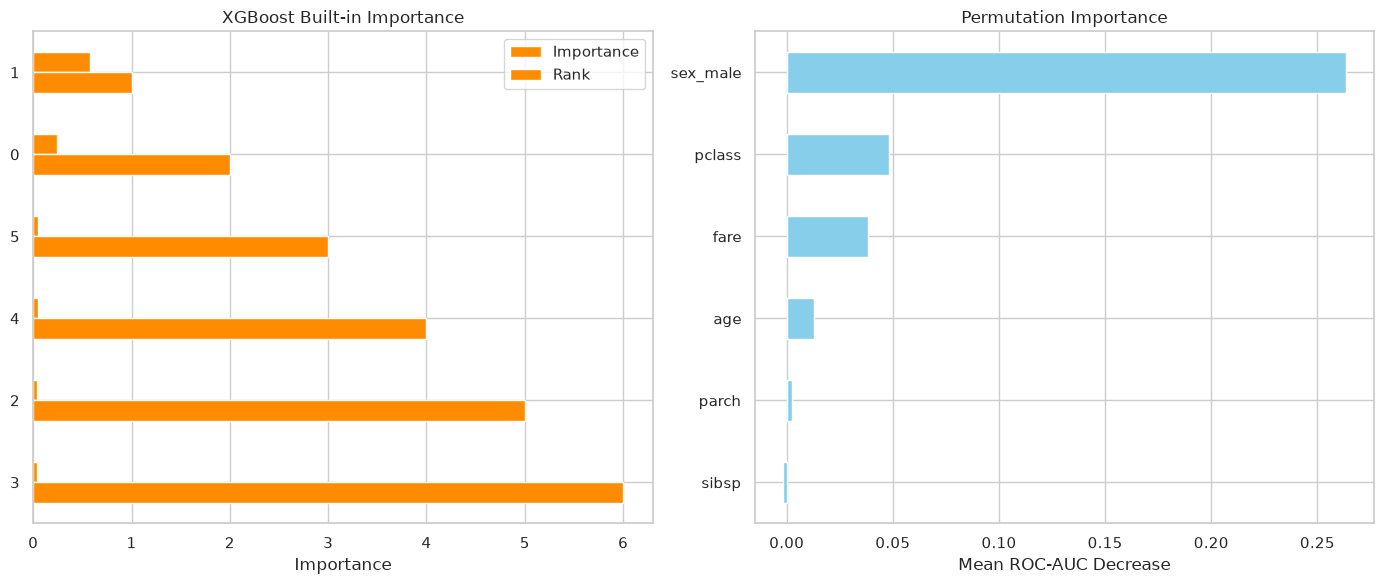

Permutation Importance:
sex_male    0.263390
pclass      0.048075
fare        0.038195
age         0.012979
parch       0.002537
sibsp      -0.001882
dtype: float64


In [127]:
# Plot both rankings side by side
perm_importance = perm_importance.drop("Rank", errors="ignore")
perm_importance = pd.to_numeric(perm_importance)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

builtin_imp.plot(kind="barh", ax=ax[0], color="darkorange")
ax[0].set_xlabel("Importance")
ax[0].set_title("XGBoost Built-in Importance")
ax[0].invert_yaxis()
perm_importance.plot(kind="barh", ax=ax[1], color="skyblue")
ax[1].set_xlabel("Mean ROC-AUC Decrease")
ax[1].set_title("Permutation Importance")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Permutation Importance:")
print(perm_importance)

In [128]:
# Add the pure-noise feature
X_train_noise = X_train.copy()
X_test_noise = X_test.copy()

rng = np.random.default_rng(2026)

X_train_noise["random noise"] = rng.normal(size=len(X_train_noise))
X_test_noise["random noise"] = rng.normal(size=len(X_test_noise))

noise_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.1, max_depth=3,
                               eval_metric="logloss", early_stopping_rounds=30, 
                               random_state=42)

noise_model.fit(X_train_noise, y_train,
               eval_set=[(X_train_noise, y_train),
                   (X_test_noise, y_test)])

[0]	validation_0-logloss:0.65561	validation_1-logloss:0.65035
[1]	validation_0-logloss:0.63080	validation_1-logloss:0.62117
[2]	validation_0-logloss:0.61026	validation_1-logloss:0.59709
[3]	validation_0-logloss:0.59313	validation_1-logloss:0.57631
[4]	validation_0-logloss:0.57873	validation_1-logloss:0.55940
[5]	validation_0-logloss:0.56654	validation_1-logloss:0.54468
[6]	validation_0-logloss:0.55621	validation_1-logloss:0.53159
[7]	validation_0-logloss:0.54731	validation_1-logloss:0.51945
[8]	validation_0-logloss:0.53965	validation_1-logloss:0.51019
[9]	validation_0-logloss:0.53305	validation_1-logloss:0.50150
[10]	validation_0-logloss:0.52656	validation_1-logloss:0.49341
[11]	validation_0-logloss:0.52144	validation_1-logloss:0.48775
[12]	validation_0-logloss:0.51629	validation_1-logloss:0.48225
[13]	validation_0-logloss:0.51171	validation_1-logloss:0.47427
[14]	validation_0-logloss:0.50781	validation_1-logloss:0.47044
[15]	validation_0-logloss:0.50424	validation_1-logloss:0.46692
[1

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [129]:
# Built-in importance with noise
noise_builtin = pd.DataFrame({
    "Features" : X_train_noise.columns,
    "Importance" : noise_model.feature_importances_
}).sort_values("Importance", ascending=False)

noise_builtin["Rank"] = range(1, len(noise_builtin) + 1)

noise_builtin

,Features,Importance,Rank
1,sex_male,0.528322,1
0,pclass,0.225301,2
4,parch,0.057189,3
5,fare,0.053930,4
2,age,0.046286,5
3,sibsp,0.046074,6
6,random noise,0.042898,7


In [130]:
# Permutation Importance with noise
noise_perm = permutation_importance(noise_model, X_test_noise, y_test, n_repeats=20,
                                   scoring="roc_auc", random_state=42)

noise_permutation = pd.DataFrame({
    "Features": X_test_noise.columns,
    "Importance": noise_perm.importances_mean
}).sort_values("Importance", ascending=False)

noise_permutation["Rank"] = range(1, len(noise_permutation) + 1)

noise_permutation

,Features,Importance,Rank
1,sex_male,0.245214,1
0,pclass,0.047235,2
5,fare,0.034005,3
6,random noise,0.010232,4
2,age,0.010090,5
3,sibsp,0.001636,6
4,parch,0.000654,7


In [131]:
noise_permutation.to_csv("noise_feature.csv", index=False)

## **Conclusion -->**
* The built-in XGBoost importance and permutation importance **[do not fully agree]** on this dataset. The rankings are [noticeably different], showing that the choice of importance method can affect how we interpret which features matter.
* The random noise feature ranked **[higher]** under the built-in importance compared with permutation importance, even though it has no meaningful relationship with the target. Impurity-based importance can inflate the apparent value of continuous features because a continuous variable has many possible split points, giving the tree many opportunities to find splits that appear useful by chance.

## **TASK 10 — Compare what the two models learned**

In [132]:
# Permutation importance for both models

# For Random Forest 
rf_perm = permutation_importance(rf, X_test, y_test, n_repeats=20,
                                scoring="roc_auc", random_state=42)

rf_importance = pd.DataFrame({
    "Features" : X_test.columns,
    "Random Forest" : rf_perm.importances_mean
}).sort_values("Random Forest", ascending=False)

rf_importance["RF Rank"] = range(1, len(rf_importance) + 1)


# For XGBoost
xgb_perm = permutation_importance(early_model, X_test, y_test, n_repeats=20,
                                 scoring="roc_auc", random_state=42)

xgb_importance = pd.DataFrame({
    "Features" : X_test.columns,
    "XGBoost" : xgb_perm.importances_mean
}).sort_values("XGBoost", ascending=False)

xgb_importance["XGB Rank"] = range(1, len(xgb_importance) + 1)

In [133]:
# Rankings side by side
comparison = pd.merge(
    rf_importance[["Features", "Random Forest", "RF Rank"]],
    xgb_importance[["Features", "XGBoost", "XGB Rank"]],
    on="Features"
).sort_values("RF Rank")

comparison

,Features,Random Forest,RF Rank,XGBoost,XGB Rank
0,sex_male,0.241046,1,0.263390,1
1,pclass,0.036277,2,0.048075,2
2,fare,0.033097,3,0.038195,3
3,parch,0.004365,4,0.002537,5
4,age,-0.008825,5,0.012979,4
5,sibsp,-0.016287,6,-0.001882,6


In [134]:
# Find biggest ranking difference
comparison["Rank Difference"] = abs(
    comparison["RF Rank"] - comparison["XGB Rank"]
)

comparison.sort_values("Rank Difference", ascending=False)

,Features,Random Forest,RF Rank,XGBoost,XGB Rank,Rank Difference
4,age,-0.008825,5,0.012979,4,1
3,parch,0.004365,4,0.002537,5,1
1,pclass,0.036277,2,0.048075,2,0
0,sex_male,0.241046,1,0.263390,1,0
2,fare,0.033097,3,0.038195,3,0
5,sibsp,-0.016287,6,-0.001882,6,0


In [135]:
comparison.to_csv("RandomForest_vs_XGB.csv", index=False)

In [136]:
most_different = comparison.loc[
    comparison["Rank Difference"].idxmax()
]

print("Most Different Features:", most_different["Features"])
print("Random Forest Rank:", most_different["RF Rank"])
print("XGBoost Rank:", most_different["XGB Rank"])

Most Different Features: parch
Random Forest Rank: 4
XGBoost Rank: 5


In [137]:
# Partial Dependence Plot for top feature
top_feature = rf_importance.iloc[0]["Features"]
print("Top Feature:", top_feature)

Top Feature: sex_male


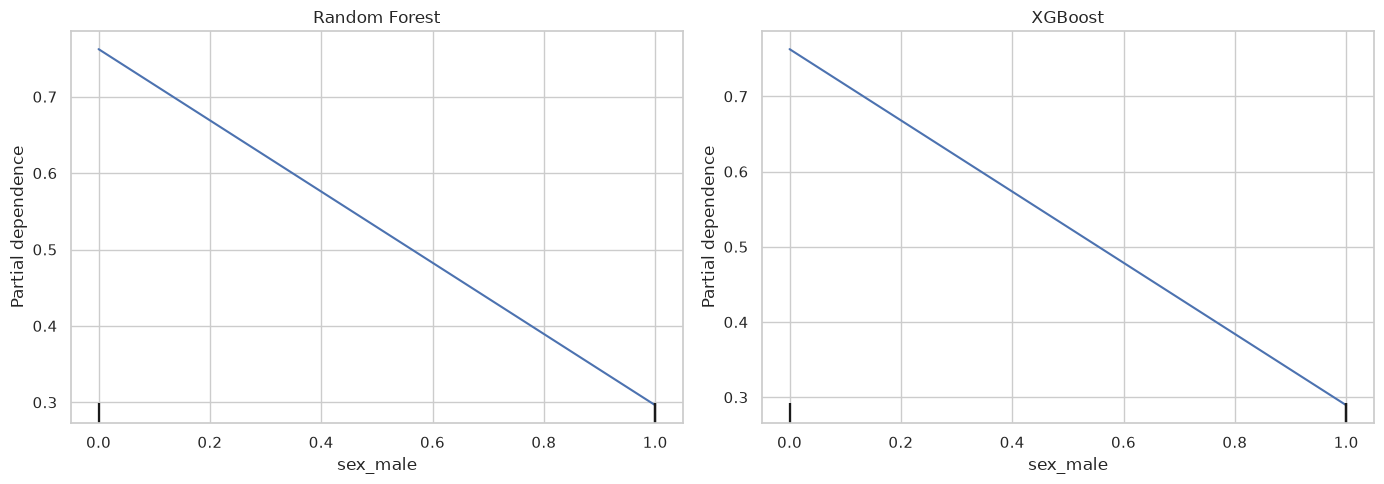

In [138]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest 
PartialDependenceDisplay.from_estimator(
    rf, X_test, [top_feature], ax=ax[0]
)
ax[0].set_title("Random Forest")

# XGBoost
PartialDependenceDisplay.from_estimator(
    early_model, X_test, [top_feature], ax=ax[1]
)
ax[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

## **Conclusion -->**  
* The partial dependence plots for the top feature, sex_male, show almost identical patterns for Random Forest and XGBoost. In both models, the predicted probability of survival is much higher for females (sex_male = 0) and lower for males (sex_male = 1). This indicates that both models learned a similar relationship between gender and survival.